# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [ ]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [ ]:
#!/bin/bash
#!curl -L -o /content/housesales-data.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  1175k      0 --:--:-- --:--:-- --:--:-- 1175k


In [ ]:
#!unzip /content/housesales-data.zip

Archive:  /content/housesales-data.zip
  inflating: kc_house_data.csv       


In [ ]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv')

X = df[['bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
       'lat', 'long', 'sqft_living15', 'sqft_lot15']].values
y = df[['price']].values
y = y.reshape(-1,1)
print(X.shape)
print(y.shape)

(21613, 17)
(21613, 1)


### Normalização dos dados

In [ ]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [ ]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 17])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 17])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [ ]:
model = torch.nn.Linear(17, 1)

### Verificando a inicialização dos parâmetros

In [ ]:
model.weight.data

tensor([[-0.2285, -0.0476, -0.1165, -0.0647, -0.2143,  0.0973, -0.2174, -0.0155,
          0.0843, -0.0818,  0.1376,  0.0306,  0.1333,  0.1556, -0.1071,  0.0881,
         -0.1049]])

### Testando o predict da rede

In [ ]:
model(torch.ones(1,17))

tensor([[-0.3952]], grad_fn=<AddmmBackward0>)

In [ ]:
X_train_tensor[:3].shape

torch.Size([3, 17])

In [ ]:
model(X_train_tensor[:3])

tensor([[-0.2862],
        [ 0.5068],
        [-0.4657]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

### Laço de treinamento

In [ ]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [ ]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [ ]:
num_epochs = 120
w0_list = [] # Stores weights
w1_list = [] # Stores biases
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/120], Train Loss: 0.299984, Val Loss: 0.328752
Epoch[40/120], Train Loss: 0.295750, Val Loss: 0.326753
Epoch[60/120], Train Loss: 0.295288, Val Loss: 0.326918
Epoch[80/120], Train Loss: 0.295226, Val Loss: 0.327058
Epoch[100/120], Train Loss: 0.295217, Val Loss: 0.327121
Epoch[120/120], Train Loss: 0.295215, Val Loss: 0.327145


## Avaliação

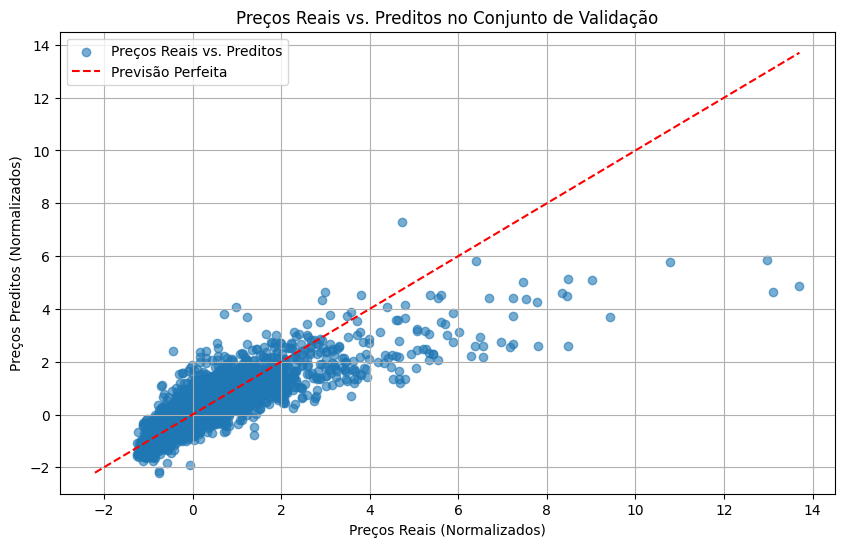

In [ ]:
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Scatter plot of actual vs. predicted values for the validation set
plt.scatter(y_val_tensor.numpy(), y_pred_val.data.numpy(), alpha=0.6, label='Preços Reais vs. Preditos')

# Plot a perfect prediction line (y=x)
max_val = max(y_val_tensor.max().item(), y_pred_val.max().item())
min_val = min(y_val_tensor.min().item(), y_pred_val.min().item())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Previsão Perfeita')

plt.xlabel('Preços Reais (Normalizados)')
plt.ylabel('Preços Preditos (Normalizados)')
plt.title('Preços Reais vs. Preditos no Conjunto de Validação')
plt.legend()
plt.grid(True)
plt.show()

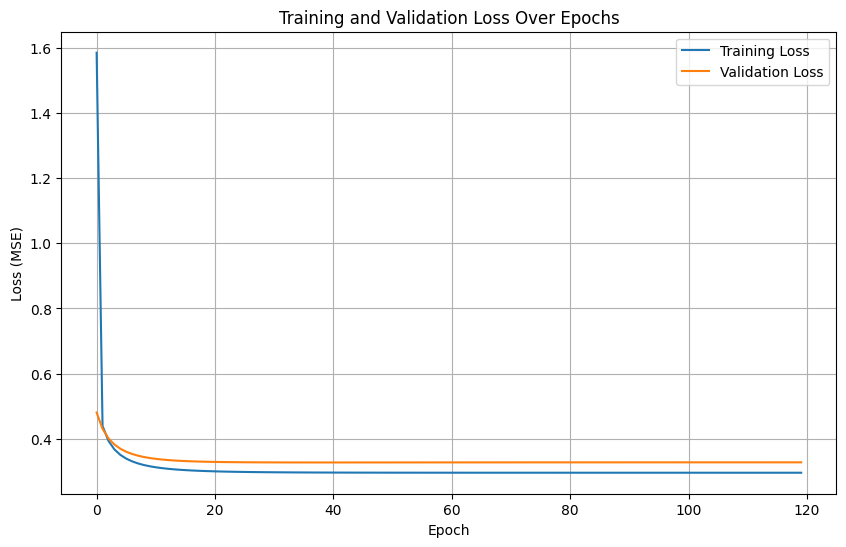

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()